<a href="https://colab.research.google.com/github/Lrnzjsph/eljay_is_available_/blob/main/Predicting_Customer_Churn_for_Canadian_SMEs_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 CANADIAN SME CHURN PROJECT: Preprocessing & Exploratory Data Analysis


In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set visual style for professional consulting-style charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
# LOAD THE DATA
# Load the Telco dataset
df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Data loaded successfully!\n")

Data loaded successfully!



In [13]:
# INITIAL INSPECTION
# Quick look at the data structure
# Number of rows and columns
df.shape

# Information about each column
df.info()

# Statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     0 non-null      object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [15]:
#Checking for missing values
df.isnull().sum()

,0
gender,0
SeniorCitizen,7043
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [16]:
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [17]:
df["TotalCharges"].dtype

dtype('float64')

In [19]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Understand the Target Variable (Churn)

Why are we doing this?

Before building a prediction model, we need to know what we're predicting and whether the data is balanced.

In [22]:
'''See how many customers stayed and how many left.
Understand whether churn is a common or rare event.'''

df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [21]:
# Check churn percentage
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


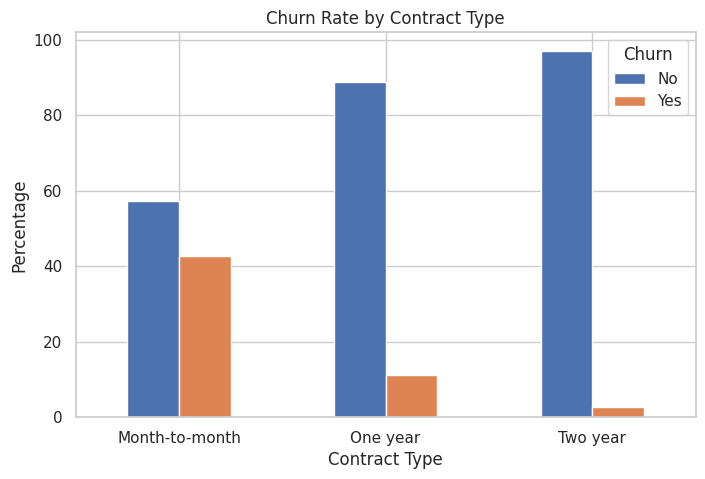

' We will see that Customers on month-to-month contracts are far more likely to churn than customers on one-year or two-year contracts.'

In [26]:
contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()
""" We will see that Customers on month-to-month contracts are far more likely to churn than customers on one-year or two-year contracts."""

What does this mean for the business?

Customers who haven't committed to a long-term contract can leave at any time. This suggests that the company should focus its retention efforts on month-to-month customers.

How could the company act on this?

Some possible strategies are:

Offer discounts for switching to a one-year or two-year contract.
Reach out to month-to-month customers before they cancel.
Provide loyalty rewards after a few months of service.

<Figure size 800x500 with 0 Axes>

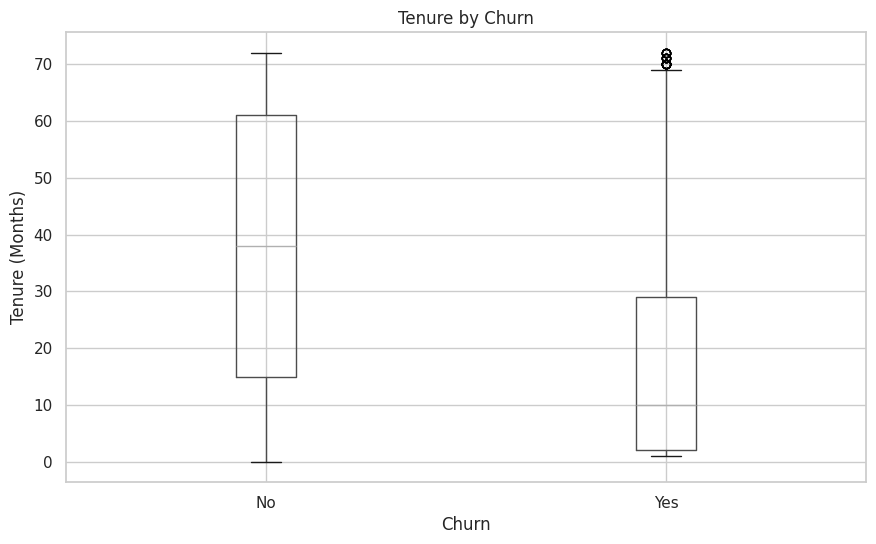

'Customers who churn generally have a much shorter tenure than those who stay.'

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")  # Removes the default pandas title
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()
'''Customers who churn generally have a much shorter tenure than those who stay.'''

What does this mean?

New customers are at the highest risk of leaving. Once customers stay with the company for a longer period, they're much more likely to remain loyal.

Business Recommendation

The company should focus on the first 12 months of a customer's journey by:

Improving onboarding.
Following up with new customers regularly.
Offering incentives to stay beyond the first year.

<Figure size 800x500 with 0 Axes>

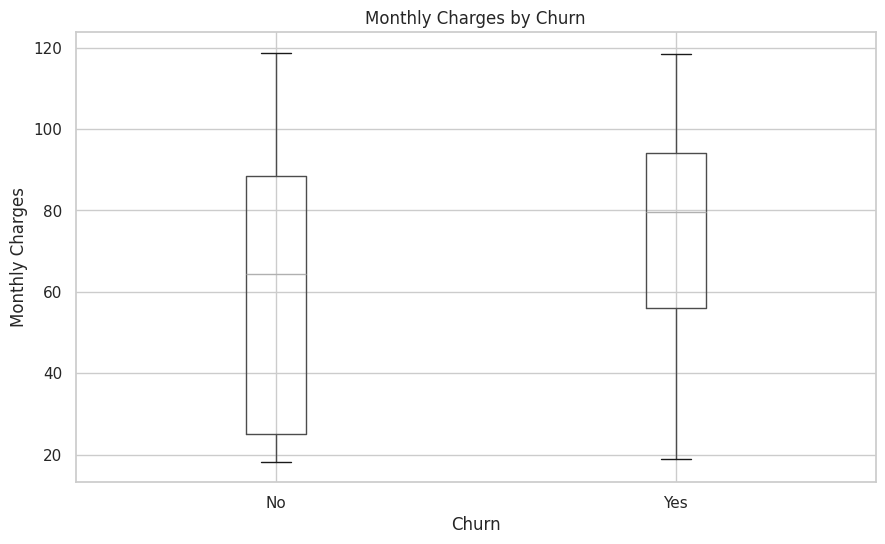

'Customers who churn tend to pay higher monthly charges than customers who stay.'

In [30]:
plt.figure(figsize=(8,5))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()
'''Customers who churn tend to pay higher monthly charges than customers who stay.'''

Customers paying higher monthly fees may feel they are not getting enough value for their money. This doesn't necessarily mean high prices cause churn, but it tells us these customers deserve closer attention.

Business Recommendation

The company should:

Monitor high-paying customers more closely.
Offer loyalty rewards or discounts.
Ensure premium customers receive excellent customer support.

In [31]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)
df[["tenure", "Tenure_Group"]].head(10)

,tenure,Tenure_Group
0,1,0-12
1,34,25-48
2,2,0-12
3,45,25-48
4,2,0-12
5,8,0-12
6,22,13-24
7,10,0-12
8,28,25-48
9,62,49-72


In [32]:
# Create another feature called Tenure_group
tenure_churn = pd.crosstab(
    df["Tenure_Group"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
Tenure_Group,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


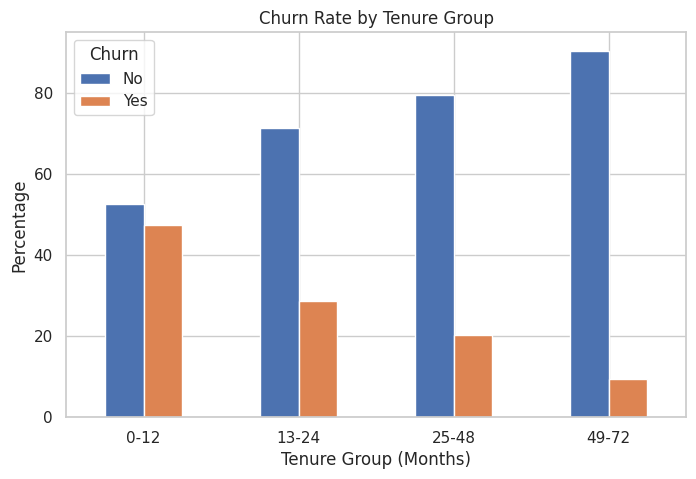

'Customers in their first 12 months have the highest churn rate.'

In [34]:
tenure_churn.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()
'''Customers in their first 12 months have the highest churn rate.'''

The first year is the critical period. If the company can keep customers beyond 12 months, they're much more likely to stay for years.

Business Recommendation

The company should create a "First-Year Retention Program" that includes:

Welcome emails
Regular check-ins
Loyalty rewards
Dedicated customer support

In [36]:
# Create new feature calle Average monthly spend
import numpy as np

df["Avg_Monthly_Spend"] = np.where(
    df["tenure"] == 0,
    0,
    df["TotalCharges"] / df["tenure"]
)
df[["TotalCharges", "tenure", "Avg_Monthly_Spend"]].head()

,TotalCharges,tenure,Avg_Monthly_Spend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


Next step:
Separate Features and Target
Why are we doing this?

A machine learning model needs two things:

Features (X): The information it will use to make predictions.
Target (y): The answer we're asking it to predict.

In our case:

X = Everything about the customer.
y = Whether the customer churned (Churn).

In [37]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7043, 21)
(7043,)


In [38]:
"""
Encode the Target Variable (y)
Why are we doing this?

Our model cannot understand the words "Yes" and "No". We need to convert them into numbers."""
#we will achieve this using Label Encoding, and it's perfect because the target has only two categories.

y = y.map({"No": 0, "Yes": 1})
y.value_counts()

,count
Churn,
0,5174
1,1869


In [39]:
"""
Encode the Categorical Features (X)
Why are we doing this?

Our machine learning model only understands numbers. Many of our columns (like Contract, InternetService, and PaymentMethod) contain text, so we need to convert them into numbers.

We'll use One-Hot Encoding because these categories have no natural order. For example, "Month-to-month" is not greater or less than "Two year".
"""
X = pd.get_dummies(X, drop_first=True)
X.head()

,tenure,MonthlyCharges,TotalCharges,Avg_Monthly_Spend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group_13-24,Tenure_Group_25-48,Tenure_Group_49-72
0,1,29.85,29.85,29.850000,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,34,56.95,1889.50,55.573529,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,2,53.85,108.15,54.075000,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,45,42.30,1840.75,40.905556,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,2,70.70,151.65,75.825000,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False


In [40]:
X.shape

(7043, 33)

Next We Split the Data into Training and Testing Sets
Why are we doing this?

We want to know if our model can predict churn for new customers it has never seen before.

So we split the data into two parts:

Training set (80%) → Used to teach the model.

Testing set (20%) → Used to evaluate how well it learned.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 33)
(1409, 33)
(5634,)
(1409,)


In [ ]:
"""
Should We Scale the Data?
Why are we doing this?

Some machine learning algorithms perform better when all numerical features are on a similar scale.
TotalCharges has much larger values than the others.
Since our goal is to build a Random Forest model first, we do not need to scale the data.

This is an important decision. We don't scale just because we can we scale only when the algorithm requires it"""


NEXT: Train Our First Machine Learning Model (Random Forest)
Why are we doing this?

Now we're ready to teach the model to recognize the patterns that distinguish customers who churn from those who stay.

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
"""
Generate the Classification Report
Why are we doing this?

Accuracy alone can be misleading.

Imagine a dataset where 95% of customers don't churn. A model that always predicts "No" would be 95% accurate—but it would completely
fail to identify customers who are about to leave.

The classification report gives us a fuller picture."""

from sklearn.metrics import classification_report
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



NEXT: Create the Confusion Matrix
Why are we doing this?

The confusion matrix shows exactly where the model got its predictions right and where it made mistakes.

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
'''The confusion matrix shows how well the model performed by comparing its predictions with the actual results. It tells us how many customers the model predicted correctly and how many it got wrong.

The diagonal values are the correct predictions, while the other two values are the mistakes. Ideally, we want the correct predictions to be as high as possible and the mistakes to be as low as possible.'''

[[923 112]
 [198 176]]


'The confusion matrix shows how well the model performed by comparing its predictions with the actual results. It tells us how many customers the model predicted correctly and how many it got wrong.\n\nThe diagonal values are the correct predictions, while the other two values are the mistakes. Ideally, we want the correct predictions to be as high as possible and the mistakes to be as low as possible.'

In [49]:
#Predict Churn Probability
churn_probability = model.predict_proba(X_test)[:, 1]
churn_probability[:10]

array([0.  , 0.8 , 0.1 , 0.33, 0.01, 0.48, 0.47, 0.07, 0.  , 0.5 ])

NEXT: Create an Action List of At-Risk Customers
Why are we doing this?

A business doesn't just want to know that the model is accurate. They want to know:

"Which customers should we contact today?"

What are we trying to achieve?

Create a list of customers sorted from highest to lowest churn risk.

In [50]:
results = X_test.copy()

results["Actual_Churn"] = y_test
results["Predicted_Churn"] = y_pred
results["Churn_Probability"] = churn_probability

results = results.sort_values(
    by="Churn_Probability",
    ascending=False
)

results.head(10)

,tenure,MonthlyCharges,TotalCharges,Avg_Monthly_Spend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group_13-24,Tenure_Group_25-48,Tenure_Group_49-72,Actual_Churn,Predicted_Churn,Churn_Probability
3682,1,69.10,69.10,69.100,True,False,False,True,False,False,...,True,False,True,False,False,False,False,1,1,1.000000
809,1,69.55,69.55,69.550,True,False,False,True,False,False,...,True,False,True,False,False,False,False,1,1,1.000000
2194,1,79.50,79.50,79.500,True,False,False,True,False,False,...,True,False,True,False,False,False,False,1,1,1.000000
1731,1,69.60,69.60,69.600,False,False,False,True,False,False,...,True,False,True,False,False,False,False,1,1,1.000000
6623,1,76.45,76.45,76.450,True,False,False,True,False,True,...,True,False,True,False,False,False,False,1,1,0.990000
1739,1,69.90,69.90,69.900,True,False,False,True,False,False,...,True,False,True,False,False,False,False,1,1,0.986667
2927,1,69.90,69.90,69.900,True,False,False,True,False,False,...,True,False,True,False,False,False,False,0,1,0.986667
2900,1,69.25,69.25,69.250,False,True,True,True,False,False,...,True,False,True,False,False,False,False,1,1,0.980000
5098,3,77.00,237.75,79.250,True,False,False,True,False,True,...,True,False,True,False,False,False,False,1,1,0.980000
3346,2,84.05,186.05,93.025,False,False,False,True,False,True,...,True,False,True,False,False,False,False,0,1,0.970000


NEXT: Find the Most Important Factors Causing Churn
Why are we doing this?

We want to know which features had the biggest influence on the model's predictions.

Instead of saying "the model predicts churn," we can say:

"These are the main reasons customers churn."

In [51]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)



,Feature,Importance
2,TotalCharges,0.156712
0,tenure,0.135439
3,Avg_Monthly_Spend,0.133599
1,MonthlyCharges,0.128291
10,InternetService_Fiber optic,0.041718
28,PaymentMethod_Electronic check,0.039270
32,Tenure_Group_49-72,0.027750
25,Contract_Two year,0.025315
4,gender_Male,0.025007
26,PaperlessBilling_Yes,0.024397


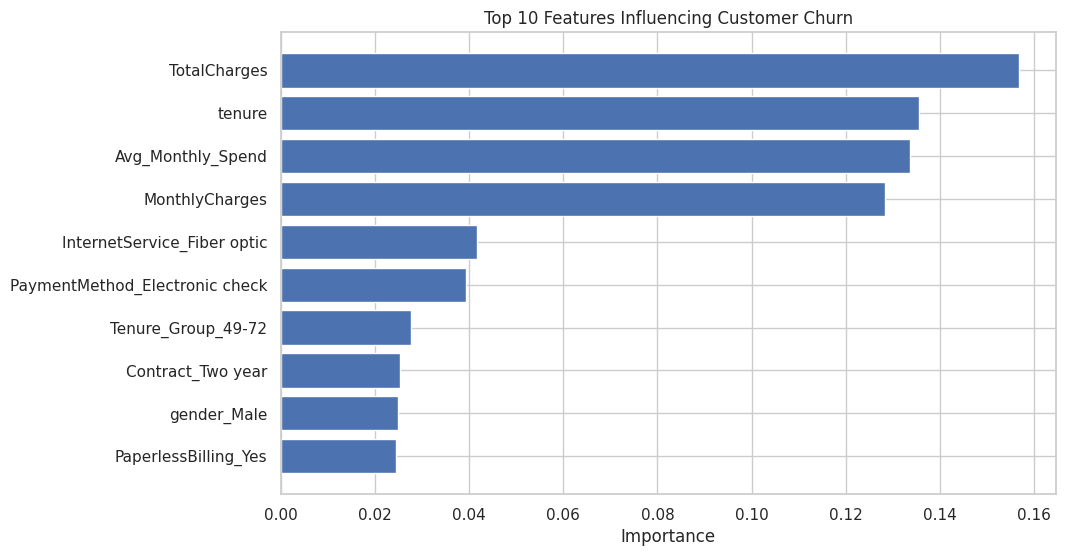

'The model identified Total Charges, Tenure, and Average Monthly Spend as the strongest predictors of customer churn.'

In [53]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()
'''The model identified Total Charges, Tenure, and Average Monthly Spend as the strongest predictors of customer churn.'''

Total Charges: The total amount a customer has spent with the company plays a significant role in determining whether they are likely to churn.

Tenure: Customers who have been with the company for a shorter period are generally more likely to leave than long-term customers.

Average Monthly Spend: Customers with higher average monthly spending tend to have a higher risk of churning, suggesting they may be more sensitive to pricing or expect greater value for the amount they pay.

These findings align with the insights we discovered during our exploratory data analysis, giving us confidence that the model has learned meaningful patterns from the data.